<a href="https://colab.research.google.com/github/jsruis/gdp-dashboard/blob/main/Te_damos_la_bienvenida_a_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_5031/2281158724.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ventas'] = df['ventas'].fillna(method='ffill') # Forward fill NaNs, or use other imputation methods


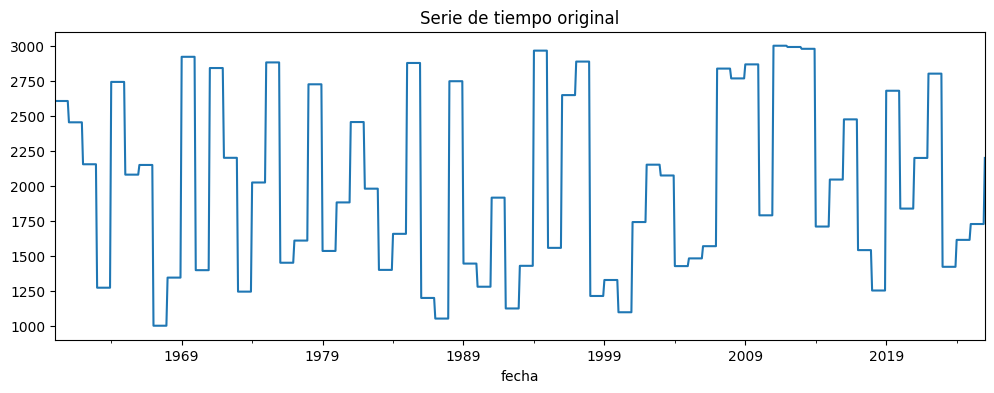

ADF Statistic: -5.2449
p-value: 0.0000


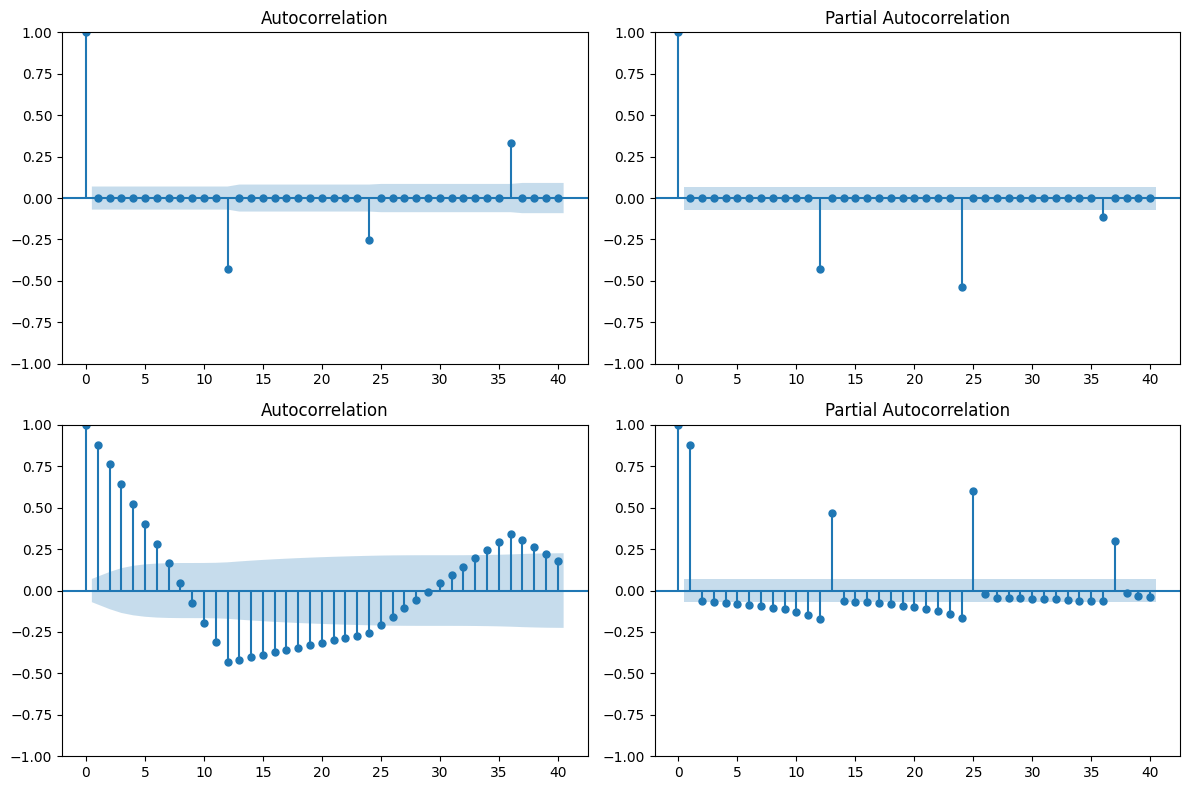

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=13.22 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=12469.722, Time=0.17 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=10874.969, Time=3.60 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=11765.792, Time=4.07 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=14380.128, Time=0.14 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=11022.525, Time=0.20 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=10619.728, Time=7.34 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=10589.344, Time=10.08 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=10651.317, Time=2.81 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=10562.508, Time=12.03 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=13.14 sec
 ARIMA(0,0,0)(2,0,2)[12] intercept   : AIC=12444.347, Time=11.11 sec
 ARIMA(2,0,0)(2,0,2)[12] intercept   : AIC=10563.356, Time=13.62 sec
 ARIMA(1,0,1)(2,0,2)[12] intercept   : AIC=10561.198, Time=12.68 sec
 ARIMA(1,0

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(1,0,1)(2,0,2)[12]           (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 517, in _fit_wrapper
    fitted = arima.fit(
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py", line 705, in fit
    mlefit = super().fit(start_p

 ARIMA(1,0,1)(2,0,2)[12]             : AIC=inf, Time=nan sec

Best model:  ARIMA(1,0,1)(2,0,2)[12] intercept
Total fit time: 208.477 seconds
                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  793
Model:             SARIMAX(1, 0, 1)x(2, 0, [1, 2], 12)   Log Likelihood               -5272.599
Date:                                 Thu, 07 May 2026   AIC                          10561.198
Time:                                         02:50:34   BIC                          10598.604
Sample:                                     01-01-1960   HQIC                         10575.574
                                          - 01-01-2026                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------

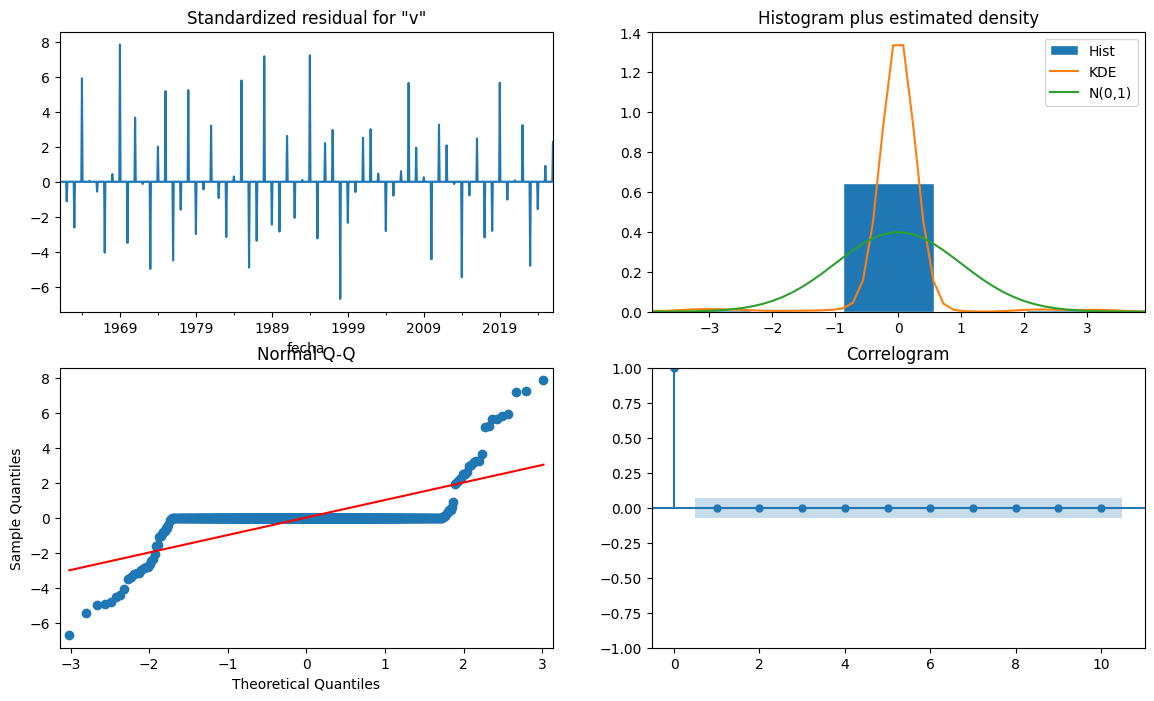

      lb_stat  lb_pvalue
10   0.000001   1.000000
20  52.165017   0.000108


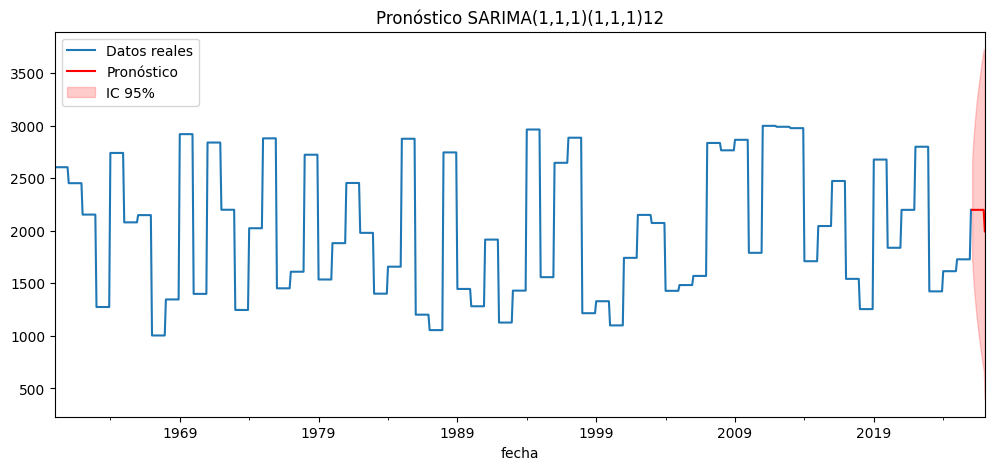

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE: 146.62
MAPE: 2.79%


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# ─── 1. CARGAR Y VISUALIZAR ───────────────────────────────────────────────────
df = pd.read_excel('Base de datos ventas.xlsx', parse_dates=['fecha'], index_col='fecha')
df = df.asfreq('MS')  # frecuencia mensual

# Handle potential NaNs introduced by asfreq or existing in the data
df['ventas'] = df['ventas'].ffill() # Forward fill NaNs, or use other imputation methods

plt.figure(figsize=(12, 4))
df['ventas'].plot(title='Serie de tiempo original')
plt.show()

# ─── 2. TEST DE ESTACIONARIEDAD (ADF) ─────────────────────────────────────────
result = adfuller(df['ventas'].dropna()) # Apply dropna() to handle any remaining NaNs for the test
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
# Si p-value > 0.05 → no estacionaria → aplicar d=1

# ─── 3. DIFERENCIAR SI ES NECESARIO ──────────────────────────────────────────
df['ventas_diff'] = df['ventas'].diff(1)      # diferenciación regular (d=1)
df['ventas_sdiff'] = df['ventas'].diff(12)    # diferenciación estacional (D=1, s=12)

# ─── 4. ACF Y PACF PARA ELEGIR p, q, P, Q ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(df['ventas_diff'].dropna(), lags=40, ax=axes[0][0])
plot_pacf(df['ventas_diff'].dropna(), lags=40, ax=axes[0][1])
plot_acf(df['ventas_sdiff'].dropna(), lags=40, ax=axes[1][0])
plot_pacf(df['ventas_sdiff'].dropna(), lags=40, ax=axes[1][1])
plt.tight_layout()
plt.show()

# ─── 5. SELECCIÓN AUTOMÁTICA CON AUTO_ARIMA (opcional) ───────────────────────
# pip install pmdarima
from pmdarima import auto_arima
auto_model = auto_arima(
    df['ventas'],
    seasonal=True, m=12,         # m = período estacional
    stepwise=True,
    information_criterion='aic',
    trace=True                   # muestra combinaciones probadas
)
print(auto_model.summary())

# ─── 6. AJUSTAR SARIMA MANUALMENTE ───────────────────────────────────────────
modelo = SARIMAX(
    df['ventas'],
    order=(1, 1, 1),             # (p, d, q)
    seasonal_order=(1, 1, 1, 12) # (P, D, Q, s)
)
resultado = modelo.fit(disp=False)
print(resultado.summary())

# ─── 7. DIAGNÓSTICO DE RESIDUOS ───────────────────────────────────────────────
resultado.plot_diagnostics(figsize=(14, 8))
plt.show()

# Test Ljung-Box: si p-value > 0.05 → residuos son ruido blanco ✓
lb_test = acorr_ljungbox(resultado.resid, lags=[10, 20], return_df=True)
print(lb_test)

# ─── 8. PRONÓSTICO ────────────────────────────────────────────────────────────
forecast = resultado.get_forecast(steps=12)
pred_ci = forecast.conf_int()

plt.figure(figsize=(12, 5))
df['ventas'].plot(label='Datos reales')
forecast.predicted_mean.plot(label='Pronóstico', color='red')
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 alpha=0.2, color='red', label='IC 95%')
plt.legend()
plt.title('Pronóstico SARIMA(1,1,1)(1,1,1)12')
plt.show()

# ─── 9. MÉTRICAS DE VALIDACIÓN ────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Dividir train/test (80/20)
train = df['ventas'][:-12]
test  = df['ventas'][-12:]

modelo_train = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
pred = modelo_train.forecast(12)

rmse = np.sqrt(mean_squared_error(test, pred))
mape = mean_absolute_percentage_error(test, pred) * 100
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')